# Lab Instructions

You have been hired by a record executive to design a guaranteed smash hit song based on data.  The exec has decided that if you make a song that has all the most popular features of recent songs then it will definitely be a hit.  So if - for example - the most common key in the Spotify data is C# then we would want the song we are designing to also be in C#.  If a "typical" value of BPM is between 120 and 130 then we would want the song we are designing to also have a tempo between 120 and 130 BMP.

Visualize and describe the distribution of:
* BPM
* Key
* Mode
* Danceability
* Energy
* Speechiness
* Acousticness

Based on your visualizations and calculations, what values for each of these features would make a song a guaranteed smash hit?  For quantitative features, you should propose a range of values.

Use a large language model to help you write code to identify if there are any songs in the Spotify dataset that meet all of the criteria we determined.  What is/are the artist(s) and title(s) of the song?  Were any of these songs actually popular?

Pick a song that you know was a smash hit. How do the values of BPM, key, mode, danceability, etc. compare to other songs? 

**Hint:**  Import the Spotify data using `df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')`.

In [49]:
import pandas as pd
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


Analyzing the data(All of which is visualized below) we can determine what features our song should have. The bpm should be between 120-130, the Key and mode should be C# and Major. Our dancability and energy should both rest between 80-85%, and our speechiness and acousticness should both be below 10%.

Using the data visualized below, we can pinpoint one song that falls withing the most common distribution for all of our criteria. This is Belly Dancer by Byor/Imanbek. It falls at 13th in the spotify charts, so it is popular, supporting the data retrieved.

In [29]:
filtered_df = df.loc[(df['bpm'] >= 120) & (df['bpm'] <= 130) & (df['mode'] == 'Major') & (df['key'] == 'C#') & (df['danceability_%'] >= 75) & (df['danceability_%'] <= 85) & (df['energy_%'] >= 80) & (df['energy_%'] <= 85)]
filtered_df.head(10)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
845,Belly Dancer,"BYOR, Imanbek",2,2022,2,18,5115,13,383835984,109,...,122,C#,Major,85,42,80,6,0,17,14


Now, lets compare this to a different song in the charts. We will use Do I Wanna Know? by Arctic Monkeys.

This track Has a bpm far below the mean, has a key of F instead of C#, has a much lower dancability and energy percentage in comparison, and even a lower speechiness compared to other hit songs. This song still manages to hit #26 in the spotify charts.

In [48]:
filtered_df = df.loc[(df['track_name'] == 'Do I Wanna Know?') & (df['artist(s)_name'] == 'Arctic Monkeys')]
filtered_df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
172,Do I Wanna Know?,Arctic Monkeys,1,2013,1,1,33783,26,1788326445,133,...,85,F,Major,55,42,53,17,0,22,3


count    953.000000
mean     122.540399
std       28.057802
min       65.000000
25%      100.000000
50%      121.000000
75%      140.000000
max      206.000000
Name: bpm, dtype: float64

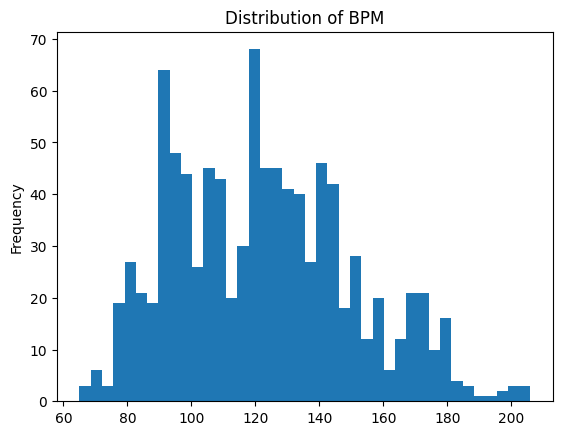

In [30]:
df['bpm'].plot(kind='hist', bins=40, title='Distribution of BPM')
df['bpm'].describe()

The Most commonly used BPM is around 120-130.

count     858
unique     11
top        C#
freq      120
Name: key, dtype: object

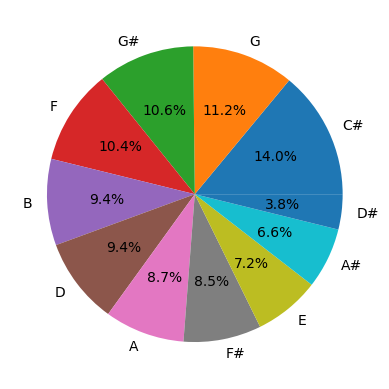

In [31]:
df['key'].value_counts().plot(kind='pie', autopct='%1.1f%%')
df['key'].describe()

The most common keys are C#, followed by G and G#.

count       953
unique        2
top       Major
freq        550
Name: mode, dtype: object

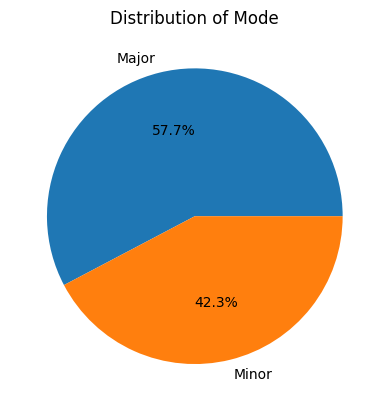

In [32]:
df['mode'].value_counts().plot(kind='pie', title='Distribution of Mode', autopct='%1.1f%%')
df['mode'].describe()

The majority of songs are in major, with 57.7%.

count    953.00000
mean      66.96957
std       14.63061
min       23.00000
25%       57.00000
50%       69.00000
75%       78.00000
max       96.00000
Name: danceability_%, dtype: float64

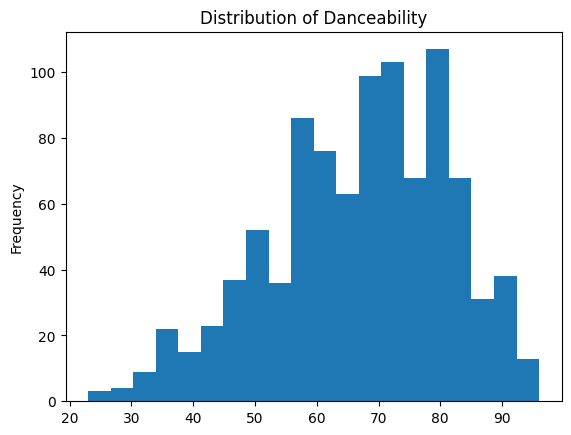

In [33]:
df['danceability_%'].plot(kind='hist', bins=20, title='Distribution of Danceability')
df['danceability_%'].describe()

The most common dancability% is around 80.

count    953.000000
mean      64.279119
std       16.550526
min        9.000000
25%       53.000000
50%       66.000000
75%       77.000000
max       97.000000
Name: energy_%, dtype: float64

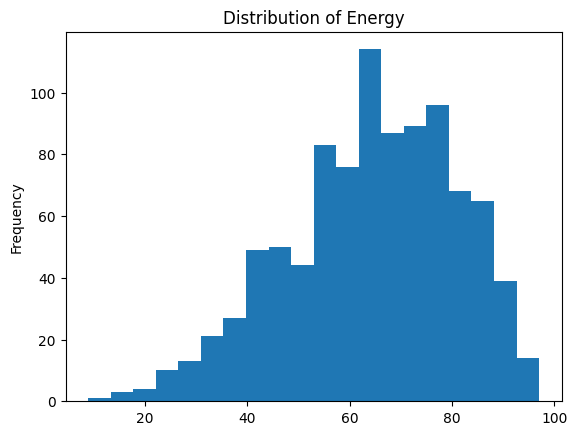

In [34]:
df['energy_%'].plot(kind='hist', bins=20, title='Distribution of Energy')
df['energy_%'].describe()

The best range for energy is around 80-85%

count    953.000000
mean      10.131165
std        9.912888
min        2.000000
25%        4.000000
50%        6.000000
75%       11.000000
max       64.000000
Name: speechiness_%, dtype: float64

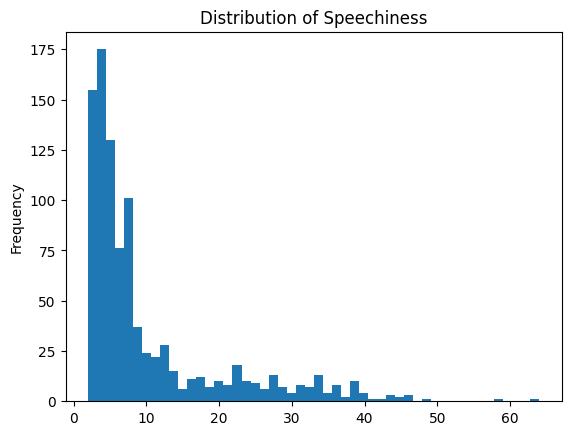

In [35]:
df['speechiness_%'].plot(kind='hist', bins=50, title='Distribution of Speechiness')
df['speechiness_%'].describe()

count    953.000000
mean      27.057712
std       25.996077
min        0.000000
25%        6.000000
50%       18.000000
75%       43.000000
max       97.000000
Name: acousticness_%, dtype: float64

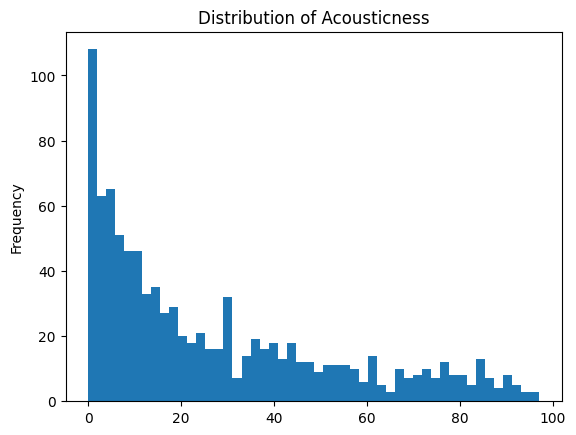

In [36]:
df['acousticness_%'].plot(kind='hist', bins=50, title='Distribution of Acousticness')
df['acousticness_%'].describe()